In [10]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Add the project root directory to the Python path so we can import quantkit
sys.path.append(os.path.abspath('..'))

from quantkit.pricing.core.instruments import Option, OptionType, OptionStyle
from quantkit.pricing.core.market import MarketData
from quantkit.pricing.core.pricer import Pricer

# Import the visualization tools we created
from quantkit.pricing.utils.graphs import (
    plot_sensitivities,
    generate_bounds_table,
    generate_american_vs_european_table,
    plot_binomial_convergence
)

# Set global plotting style for professional academic charts
plt.style.use('seaborn-v0_8-darkgrid')

In [11]:
# 1. Setup Standard Market Conditions
market = MarketData(
    spot=100.0, 
    rate=0.05, 
    volatility=0.2, 
    dividend_yield=0.0
)

# 2. Define standard American Options for our tests
am_put = Option(strike=100.0, maturity=1.0, option_type=OptionType.PUT, style=OptionStyle.AMERICAN)
am_call = Option(strike=100.0, maturity=1.0, option_type=OptionType.CALL, style=OptionStyle.AMERICAN)

print(f"Market Initialized: Spot=${market.spot}, Rate={market.rate*100}%, Vol={market.volatility*100}%")

Market Initialized: Spot=$100.0, Rate=5.0%, Vol=20.0%


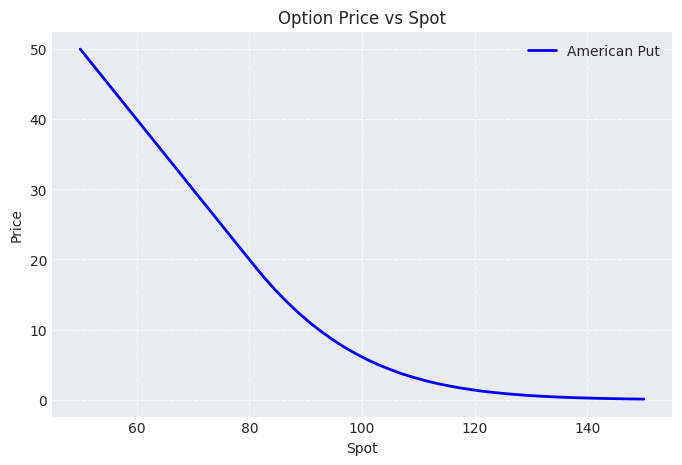

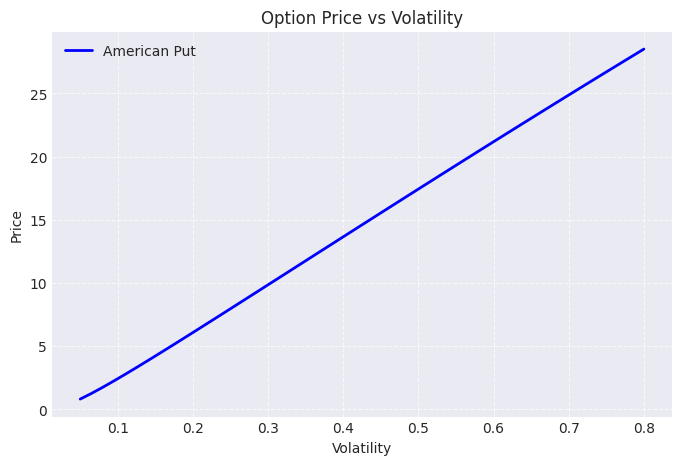

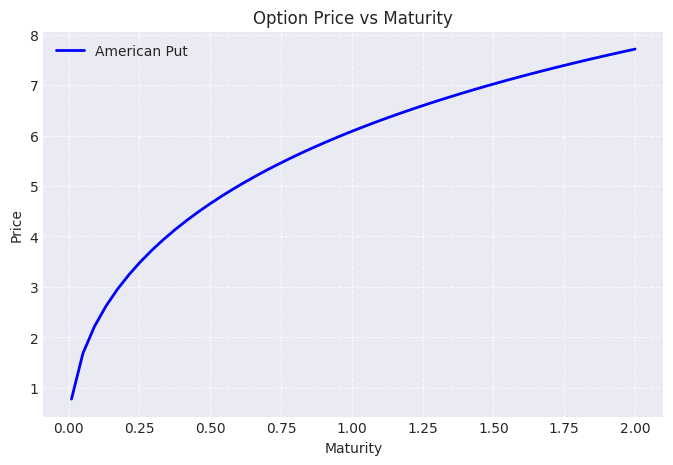

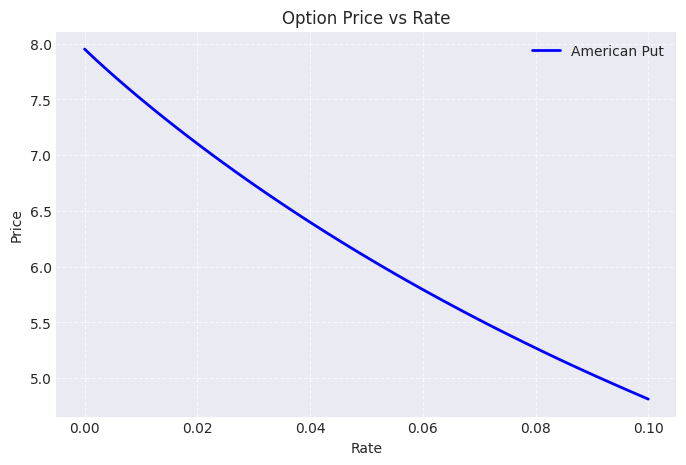

In [12]:
# Define ranges for our independent variables
spot_range = np.linspace(50, 150, 50)
vol_range = np.linspace(0.05, 0.80, 50)
time_range = np.linspace(0.01, 2.0, 50)
rate_range = np.linspace(0.0, 0.10, 50)

# 1. American Put Price vs. Spot Price (Delta proxy)
plot_sensitivities(am_put, market, param_name='spot', param_range=spot_range, engine="binomial", steps=150)

# 2. American Put Price vs. Volatility (Vega proxy)
plot_sensitivities(am_put, market, param_name='volatility', param_range=vol_range, engine="binomial", steps=150)

# 3. American Put Price vs. Time to Maturity (Theta proxy)
plot_sensitivities(am_put, market, param_name='maturity', param_range=time_range, engine="binomial", steps=150)

plot_sensitivities(am_put, market, param_name='rate', param_range=rate_range, engine="binomial", steps=150)

In [13]:
# Create a mix of ITM, ATM, and OTM American Options
options_to_test = [
    Option(80.0, 1.0, OptionType.PUT, OptionStyle.AMERICAN),  # OTM Put
    Option(100.0, 1.0, OptionType.PUT, OptionStyle.AMERICAN), # ATM Put
    Option(120.0, 1.0, OptionType.PUT, OptionStyle.AMERICAN), # ITM Put
    Option(80.0, 1.0, OptionType.CALL, OptionStyle.AMERICAN), # ITM Call
    Option(100.0, 1.0, OptionType.CALL, OptionStyle.AMERICAN) # ATM Call
]

# Generate and display the bounds table
bounds_df = generate_bounds_table(options_to_test, market, engine="binomial")
display(bounds_df)

,Style,Type,Strike,Maturity,Lower Bound,Actual Price,Upper Bound,Valid?
0,American,Put,80.0,1.0,0.0000,0.7280,80.0,True
1,American,Put,100.0,1.0,0.0000,6.0824,100.0,True
2,American,Put,120.0,1.0,14.1475,20.1303,120.0,True
3,American,Call,80.0,1.0,23.9016,24.5935,100.0,True
4,American,Call,100.0,1.0,4.8771,10.4306,100.0,True


In [14]:
# Test across a grid of strikes and maturities
strikes_grid = [80.0, 100.0, 120.0]
maturities_grid = [0.5, 1.0, 2.0]

# Generate table for Puts (where early exercise premium is most visible without dividends)
premium_df = generate_american_vs_european_table(
    market=market, 
    strikes=strikes_grid, 
    maturities=maturities_grid, 
    opt_type=OptionType.PUT
)

display(premium_df)

,Type,Strike,Maturity,European Price,American Price,Early Exercise Premium,Invariant Holds?
0,Put,80.0,0.5,0.1996,0.2049,0.0053,True
1,Put,80.0,1.0,0.6866,0.7238,0.0372,True
2,Put,80.0,2.0,1.5074,1.6717,0.1643,True
3,Put,100.0,0.5,4.4103,4.6514,0.2411,True
4,Put,100.0,1.0,5.5602,6.0850,0.5248,True
5,Put,100.0,2.0,6.5917,7.7158,1.1241,True
6,Put,120.0,0.5,18.0546,20.0000,1.9454,True
7,Put,120.0,1.0,17.4003,20.1351,2.7348,True
8,Put,120.0,2.0,16.4898,20.6754,4.1856,True


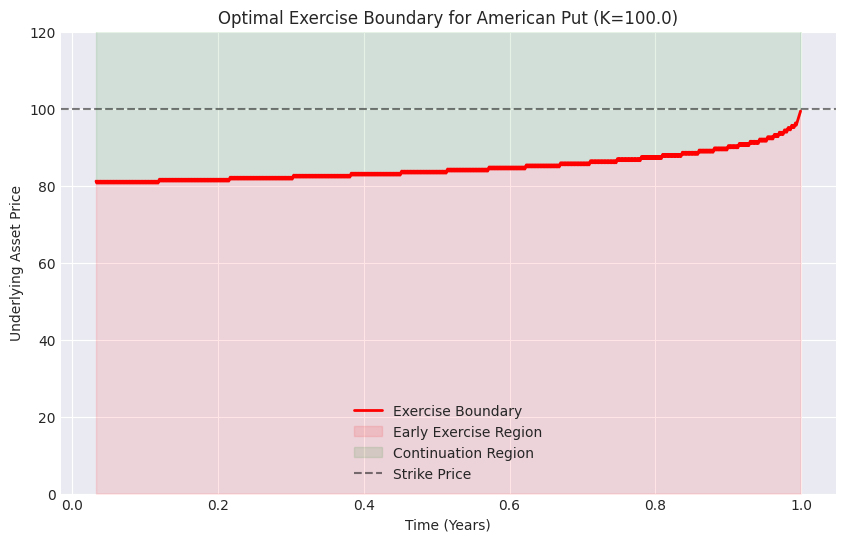

In [15]:
def plot_exercise_boundary(option: Option, market: MarketData, steps: int = 500):
    """Executes the Binomial Tree and plots the optimal early exercise boundary."""
    
    # Run the pricer to get the OptionPriceResult object
    res = Pricer.price(option, market, engine="binomial", steps=steps)
    
    if len(res.boundary_times) == 0:
        print("No early exercise boundary found (European option or suboptimal to exercise).")
        return
        
    plt.figure(figsize=(10, 6))
    
    # Plot the boundary
    plt.plot(res.boundary_times, res.boundary_spots, color='red', linewidth=2, label='Exercise Boundary')
    
    # Fill the regions
    if option.option_type == OptionType.PUT:
        plt.fill_between(res.boundary_times, 0, res.boundary_spots, color='red', alpha=0.1, label='Early Exercise Region')
        plt.fill_between(res.boundary_times, res.boundary_spots, market.spot * 2, color='green', alpha=0.1, label='Continuation Region')
        plt.ylim(0, option.strike * 1.2)
    else:
        plt.fill_between(res.boundary_times, res.boundary_spots, market.spot * 3, color='red', alpha=0.1, label='Early Exercise Region')
        plt.fill_between(res.boundary_times, 0, res.boundary_spots, color='green', alpha=0.1, label='Continuation Region')
        plt.ylim(0, option.strike * 2)

    plt.title(f'Optimal Exercise Boundary for American {option.option_type.value.capitalize()} (K={option.strike})')
    plt.xlabel('Time (Years)')
    plt.ylabel('Underlying Asset Price')
    plt.axhline(y=option.strike, color='black', linestyle='--', alpha=0.5, label='Strike Price')
    plt.legend(loc='best')
    plt.show()

# Plot the boundary for a deep ITM American Put using a high-step tree for a smooth curve
plot_exercise_boundary(
    option=Option(strike=100.0, maturity=1.0, option_type=OptionType.PUT, style=OptionStyle.AMERICAN),
    market=market,
    steps=1000 
)

Computing tree prices across varying step sizes. This may take a few seconds...


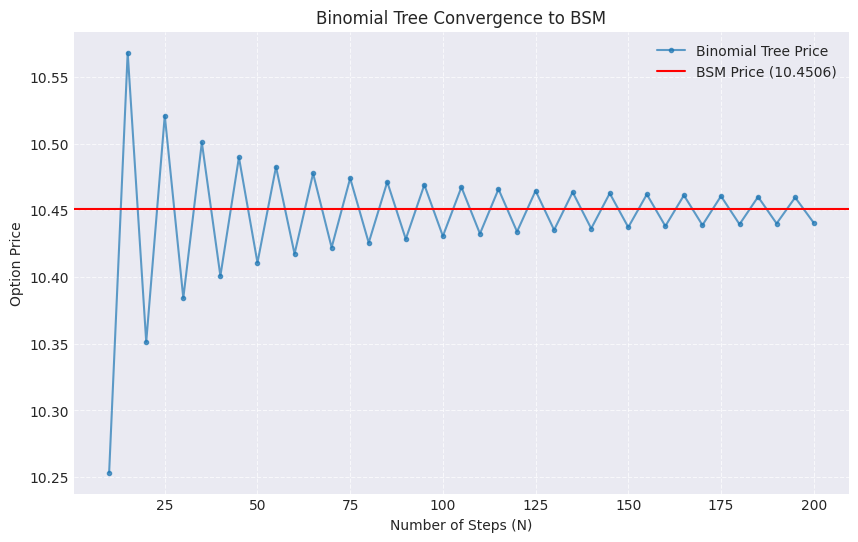

In [16]:
# To prove our tree converges to continuous BSM, we must compare it to a European Option
# (or an American Call with no dividends, but we will use European here to be strict).

eur_call_for_test = Option(
    strike=100.0, 
    maturity=1.0, 
    option_type=OptionType.CALL, 
    style=OptionStyle.EUROPEAN
)

# Test the tree from 10 steps up to 200 steps, jumping by 5 steps at a time
steps_to_test = range(10, 205, 5)

print("Computing tree prices across varying step sizes. This may take a few seconds...")

# Plot the convergence
plot_binomial_convergence(
    option=eur_call_for_test, 
    market=market, 
    step_range=steps_to_test
)